<a href="https://colab.research.google.com/github/Rodriguez-9819/Aaron_INFO4670_Fall2026/blob/main/Assignment3_Aaron_Rodriguez.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment 3 — Association Rule Mining

**Student:** Aaron Rodriguez  
**Dataset:** `bread_basket.csv`

The supplied CSV contains **20,507 item records, 9,465 unique transactions,
and 94 distinct items**. The template's original figure of 11,569 is the number
of afternoon item records, rather than the number of unique transactions.
All support calculations use unique transactions as their denominator.

**Sections:**
1. Setup & Data Load
2. EDA (a–e)
3. Frequent Itemset Mining (FP-Growth)
4. Association Rules + Report Table
5. Rule Subgraph (Bread, Coffee, Cake, Tea)
6. Interpretation Prompt

This is the completed instructor-provided template. Its original cells and
identifiers are retained, with the missing EDA (e) and rule-subgraph sections added.


## 1) Setup & Data Load (10 pts)

Place `bread_basket.csv` in the same folder as this notebook. The setup cell
installs a required package only if it is missing and reports the installed versions.
The CSV is retained in its original row format for the descriptive overview.
For market-basket analysis, repeated occurrences of an item in a transaction
count as a single presence, because association rules concern whether an item
is in a basket.


In [1]:
# Environment setup and data loading.
import importlib.util
import subprocess
import sys
from importlib.metadata import version
from pathlib import Path

requirements = {
    "pandas": "pandas>=2.0",
    "numpy": "numpy",
    "matplotlib": "matplotlib",
    "mlxtend": "mlxtend==0.23.4",
    "networkx": "networkx>=3.3,<4",
}
missing = [requirement for module, requirement in requirements.items()
           if importlib.util.find_spec(module) is None]
if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", *missing])

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
from matplotlib.lines import Line2D
from IPython.display import display, Markdown
from mlxtend.frequent_patterns import fpgrowth, association_rules

pd.set_option("display.max_rows", 120)
pd.set_option("display.max_columns", 20)
pd.set_option("display.max_colwidth", 80)
plt.rcParams.update({"figure.dpi": 120, "font.size": 10})

DATA_PATH = Path("bread_basket.csv")
if not DATA_PATH.is_file():
    raise FileNotFoundError("Place bread_basket.csv beside this notebook, then run all cells.")

df = pd.read_csv(DATA_PATH)
required_columns = ["transaction", "item", "date_time", "time",
                    "period_day", "weekday_weekend"]
assert set(required_columns).issubset(df.columns), "Unexpected CSV columns."
assert df[required_columns].notna().all().all(), "Required values are missing."

transaction_items = df[["transaction", "item"]].drop_duplicates()
n_transactions = df["transaction"].nunique()
n_items = df["item"].nunique()
subtitle = "Aaron Rodriguez"

print(f"Item records: {len(df):,}")
print(f"Unique transactions: {n_transactions:,}")
print(f"Distinct items: {n_items:,}")
print(f"Repeated transaction-item occurrences: {len(df) - len(transaction_items):,}")
display(df.head(10))
display(pd.DataFrame({
    "Package": list(requirements),
    "Version": [version(package) for package in requirements],
}))


Item records: 20,507
Unique transactions: 9,465
Distinct items: 94
Repeated transaction-item occurrences: 1,620


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,transaction,item,date_time,time,period_day,weekday_weekend
0,1,Bread,30/10/2016,9:58,morning,weekend
1,2,Scandinavian,30/10/2016,10:05,morning,weekend
2,2,Scandinavian,30/10/2016,10:05,morning,weekend
3,3,Hot chocolate,30/10/2016,10:07,morning,weekend
4,3,Jam,30/10/2016,10:07,morning,weekend
5,3,Cookies,30/10/2016,10:07,morning,weekend
6,4,Muffin,30/10/2016,10:08,morning,weekend
7,5,Coffee,30/10/2016,10:13,morning,weekend
8,5,Pastry,30/10/2016,10:13,morning,weekend
9,5,Bread,30/10/2016,10:13,morning,weekend


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,Package,Version
0,pandas,2.2.3
1,numpy,2.1.3
2,matplotlib,3.10.0
3,mlxtend,0.23.4
4,networkx,3.6.1


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

## 2) EDA (a–e) (30 pts)
### a) List variables and their dtypes (5 pts)

In [2]:
# a) Variables and original CSV data types.
descriptions = {
    "transaction": "Basket identifier; repeated for every item in the same transaction.",
    "item": "Product name; a categorical variable.",
    "date_time": "Calendar date stored as text in two formats.",
    "time": "Time of purchase stored as text in 24-hour or AM/PM format.",
    "period_day": "Morning, afternoon, evening, or night.",
    "weekday_weekend": "Weekday or weekend category.",
}
variable_table = pd.DataFrame({
    "Variable": df.columns,
    "Data type": df.dtypes.astype(str).values,
    "Non-null records": df.notna().sum().values,
    "Description": [descriptions[column] for column in df.columns],
})
display(variable_table)
print("Transaction is an identifier, so its numeric mean is not a sales statistic.")
print("The date and time strings are parsed explicitly in part (e).")


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

,Variable,Data type,Non-null records,Description
0,transaction,int64,20507,Basket identifier; repeated for every item in the same transaction.
1,item,object,20507,Product name; a categorical variable.
2,date_time,object,20507,Calendar date stored as text in two formats.
3,time,object,20507,Time of purchase stored as text in 24-hour or AM/PM format.
4,period_day,object,20507,"Morning, afternoon, evening, or night."
5,weekday_weekend,object,20507,Weekday or weekend category.


Transaction is an identifier, so its numeric mean is not a sales statistic.
The date and time strings are parsed explicitly in part (e).


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

### b) "Statistics" overview (5 pts)
Use `describe(include='all')` as a stand‑in for Statistics.

In [3]:
# b) Statistical overview of the original item-record table.
display(df.describe(include="all").round(3))

quality_summary = pd.DataFrame({
    "Measure": ["Item records", "Unique transactions", "Distinct items",
                "Missing values", "Repeated transaction-item occurrences"],
    "Value": [len(df), n_transactions, n_items, int(df.isna().sum().sum()),
              len(df) - len(transaction_items)],
})
display(quality_summary)
print("describe() summarizes item records; product frequency here may include repeats")
print("within a basket. Parts (c) and (d) instead count unique transactions per item.")


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

,transaction,item,date_time,time,period_day,weekday_weekend
count,20507.000,20507,20507,20507,20507,20507
unique,NaN,94,159,1255,4,2
top,NaN,Coffee,2017-02-04,11:06,afternoon,weekday
freq,NaN,5471,292,52,11569,12807
mean,4976.202,NaN,NaN,NaN,NaN,NaN
std,2796.203,NaN,NaN,NaN,NaN,NaN
min,1.000,NaN,NaN,NaN,NaN,NaN
25%,2552.000,NaN,NaN,NaN,NaN,NaN
50%,5137.000,NaN,NaN,NaN,NaN,NaN
75%,7357.000,NaN,NaN,NaN,NaN,NaN


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,Measure,Value
0,Item records,20507
1,Unique transactions,9465
2,Distinct items,94
3,Missing values,0
4,Repeated transaction-item occurrences,1620


describe() summarizes item records; product frequency here may include repeats
within a basket. Parts (c) and (d) instead count unique transactions per item.


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

### c) Bar plot — count of **unique transactions per item** (10 pts)
Set the subtitle to your **FirstName LastName**.

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

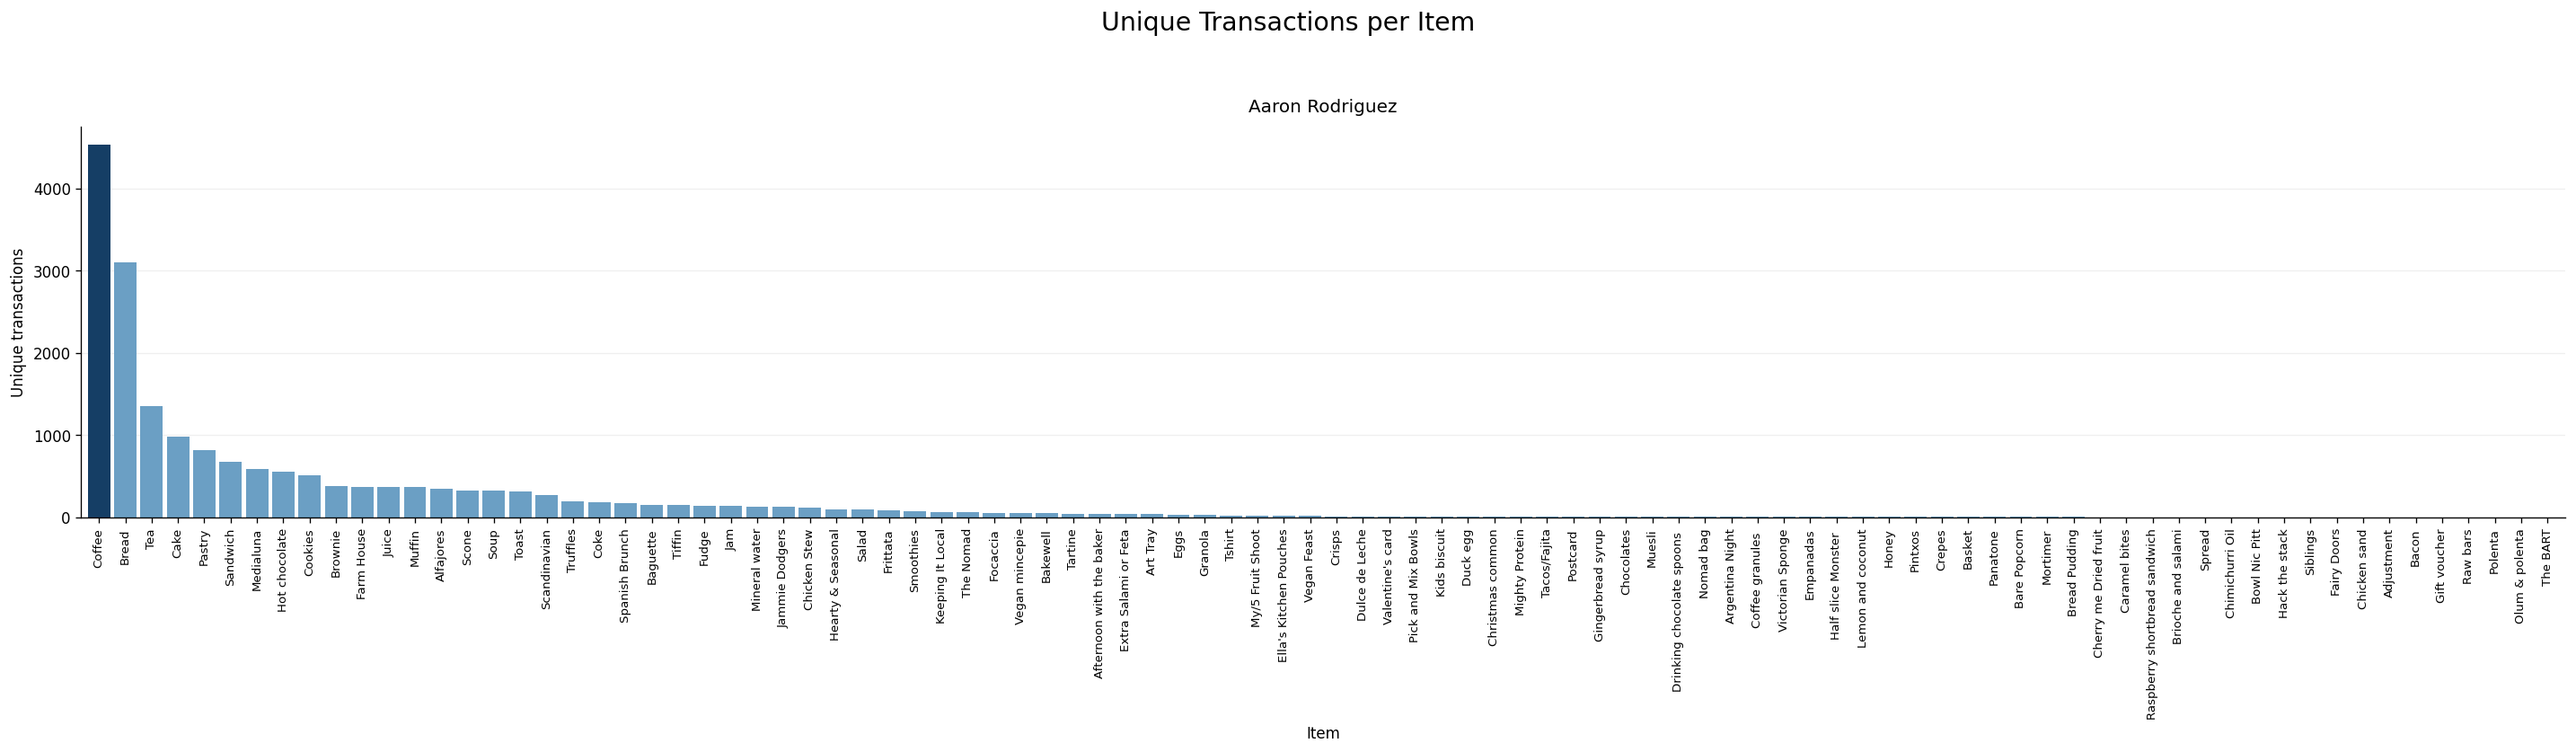

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

In [4]:
# c) Unique transaction counts for all 94 items.
item_counts = (df.groupby("item")["transaction"].nunique()
              .sort_values(ascending=False))

fig, ax = plt.subplots(figsize=(24, 7))
colors = ["#153e65" if item == "Coffee" else "#6b9fc4"
          for item in item_counts.index]
item_counts.plot(kind="bar", ax=ax, color=colors, width=0.85)
fig.suptitle("Unique Transactions per Item", fontsize=17, y=0.99)
ax.set_title(subtitle, fontsize=12, pad=10)
ax.set_xlabel("Item")
ax.set_ylabel("Unique transactions")
ax.tick_params(axis="x", labelrotation=90, labelsize=8)
ax.grid(axis="y", alpha=0.2)
ax.set_axisbelow(True)
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout(rect=(0, 0, 1, 0.95))
plt.show()


### d) Report counts for Coffee, Tea, Alfajores, Juice, and Chicken Stew (10 pts)

In [5]:
# d) Requested product counts, based on distinct baskets.
requested_items = ["Coffee", "Tea", "Alfajores", "Juice", "Chicken Stew"]
selected_counts = item_counts.reindex(requested_items)
assert selected_counts.notna().all(), "A requested product is missing from the CSV."
count_report = pd.DataFrame({
    "Item": requested_items,
    "Unique transactions": selected_counts.astype(int).values,
    "Share of all transactions (%)": (selected_counts / n_transactions * 100).round(2).values,
})
display(count_report)


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

,Item,Unique transactions,Share of all transactions (%)
0,Coffee,4528,47.84
1,Tea,1350,14.26
2,Alfajores,344,3.63
3,Juice,365,3.86
4,Chicken Stew,123,1.30


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

### e) Basket structure and transaction timing

The rubric requests EDA (a–e), while the provided template contains (a–d).
This additional subsection examines the number of distinct items per basket
and the number of unique transactions during each part of the day.

Dates mix `DD/MM/YYYY` with `YYYY-MM-DD`; times mix `HH:MM` with AM/PM values.
Each format is parsed separately to preserve the correct calendar dates.
Repeated product occurrences remain in the raw data, but are counted once
when computing basket sizes.

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

,Distinct items per basket
count,9465.000
mean,1.995
std,1.130
min,1.000
25%,1.000
50%,2.000
75%,3.000
max,10.000


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,Part of day,Unique transactions,Share (%)
0,morning,4103,43.35
1,afternoon,5089,53.77
2,evening,261,2.76
3,night,12,0.13


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

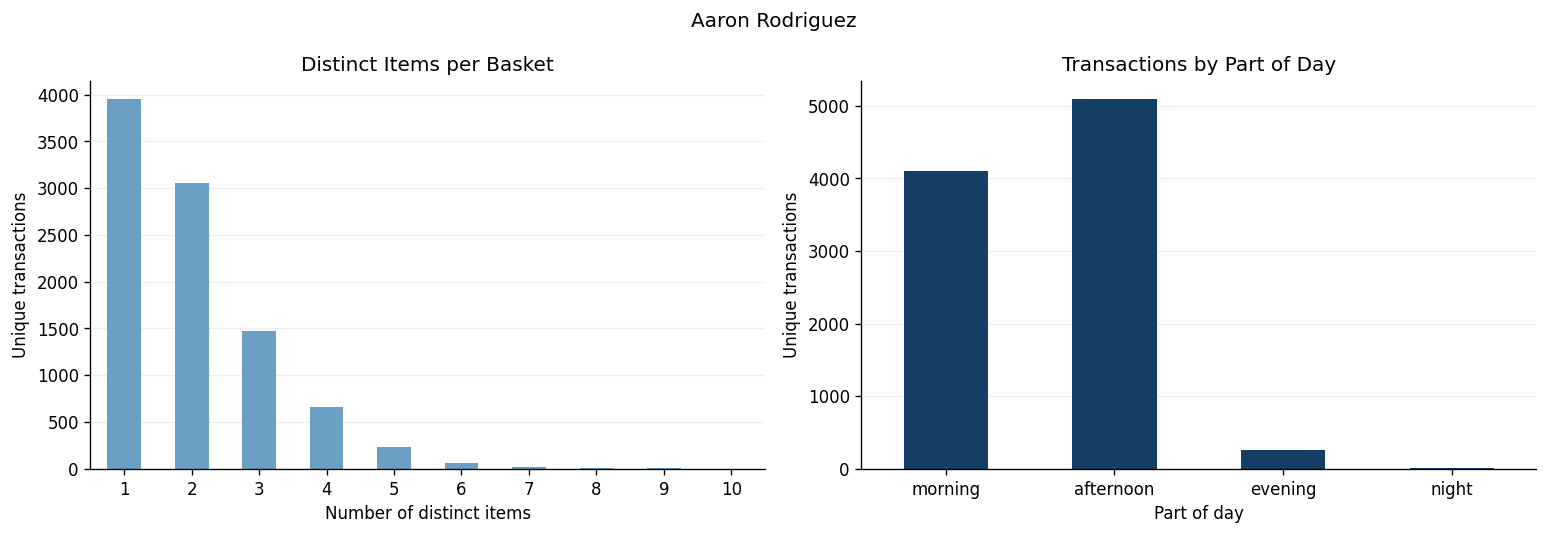

Recorded dates: 2016-10-30 to 2017-04-09
Mean distinct items per basket: 2.00; median: 2; maximum: 10.
Afternoon has the most transactions. These are historical basket counts;
the dataset does not provide sales revenue or customer identities.


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

In [6]:
# e) Basket sizes and unique transaction timing.
metadata_columns = ["date_time", "time", "period_day", "weekday_weekend"]
assert df.groupby("transaction")[metadata_columns].nunique().le(1).all().all()
transaction_meta = df.drop_duplicates("transaction").copy()

slash_dates = transaction_meta["date_time"].str.contains("/", regex=False)
parsed_dates = pd.Series(pd.NaT, index=transaction_meta.index, dtype="datetime64[ns]")
parsed_dates.loc[slash_dates] = pd.to_datetime(
    transaction_meta.loc[slash_dates, "date_time"], format="%d/%m/%Y")
parsed_dates.loc[~slash_dates] = pd.to_datetime(
    transaction_meta.loc[~slash_dates, "date_time"], format="%Y-%m-%d")

ampm_times = transaction_meta["time"].str.contains("AM|PM", case=False)
parsed_times = pd.Series(pd.NaT, index=transaction_meta.index, dtype="datetime64[ns]")
parsed_times.loc[ampm_times] = pd.to_datetime(
    transaction_meta.loc[ampm_times, "time"], format="%I:%M:%S %p")
parsed_times.loc[~ampm_times] = pd.to_datetime(
    transaction_meta.loc[~ampm_times, "time"], format="%H:%M")

transaction_meta["timestamp"] = parsed_dates + (parsed_times - parsed_times.dt.normalize())
assert transaction_meta["timestamp"].notna().all()
basket_sizes = transaction_items.groupby("transaction").size()
display(basket_sizes.describe().rename("Distinct items per basket").to_frame().round(3))

period_order = ["morning", "afternoon", "evening", "night"]
period_counts = (transaction_meta["period_day"].value_counts()
                 .reindex(period_order, fill_value=0))
period_report = pd.DataFrame({
    "Part of day": period_order,
    "Unique transactions": period_counts.values,
    "Share (%)": (period_counts / n_transactions * 100).round(2).values,
})
display(period_report)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
size_counts = basket_sizes.value_counts().sort_index()
size_counts.plot(kind="bar", ax=axes[0], color="#6b9fc4", rot=0)
axes[0].set_title("Distinct Items per Basket")
axes[0].set_xlabel("Number of distinct items")
axes[0].set_ylabel("Unique transactions")
period_counts.plot(kind="bar", ax=axes[1], color="#153e65", rot=0)
axes[1].set_title("Transactions by Part of Day")
axes[1].set_xlabel("Part of day")
axes[1].set_ylabel("Unique transactions")
for ax in axes:
    ax.grid(axis="y", alpha=0.2)
    ax.set_axisbelow(True)
    ax.spines[["top", "right"]].set_visible(False)
fig.suptitle(subtitle, fontsize=12)
fig.tight_layout()
plt.show()

print(f"Recorded dates: {transaction_meta['timestamp'].min():%Y-%m-%d} to "
      f"{transaction_meta['timestamp'].max():%Y-%m-%d}")
print(f"Mean distinct items per basket: {basket_sizes.mean():.2f}; "
      f"median: {basket_sizes.median():.0f}; maximum: {basket_sizes.max():.0f}.")
print("Afternoon has the most transactions. These are historical basket counts;")
print("the dataset does not provide sales revenue or customer identities.")

## 3) Frequent Itemset Mining with FP-Growth (25 pts)

**Minimum support: 0.02.** We pivot the transaction-item data into a boolean
transaction × item table. `True` means that an item appears at least once in a
basket. FP-Growth builds an FP-tree and mines conditional patterns without
explicitly generating candidate itemsets.

An itemset must occur in at least 2% of all 9,465 transactions, or **190
transactions**, to be retained. Items below that threshold are still included
in the input table; FP-Growth applies the support filter.


In [7]:
# Boolean one-hot basket matrix and FP-Growth mining.
basket = pd.crosstab(transaction_items["transaction"], transaction_items["item"]).gt(0)
MIN_SUPPORT = 0.02
frequent_itemsets = fpgrowth(basket, min_support=MIN_SUPPORT, use_colnames=True)
frequent_itemsets["length"] = frequent_itemsets["itemsets"].map(len)
frequent_itemsets["transaction_count"] = (
    frequent_itemsets["support"] * n_transactions).round().astype(int)

def format_itemset(items):
    return "{" + ", ".join(sorted(items)) + "}"

frequent_itemsets["itemset_label"] = frequent_itemsets["itemsets"].map(format_itemset)
frequent_itemsets = frequent_itemsets.sort_values(
    ["support", "length", "itemset_label"], ascending=[False, True, True]
).reset_index(drop=True)

frequent_itemset_report = frequent_itemsets[
    ["itemset_label", "length", "transaction_count", "support"]
].rename(columns={"itemset_label": "Itemset", "length": "Number of items",
                  "transaction_count": "Transactions", "support": "Support"})

print(f"One-hot matrix: {basket.shape[0]:,} transactions × {basket.shape[1]} items")
print(f"Boolean columns: {basket.dtypes.eq(bool).all()}")
print(f"Minimum support: {MIN_SUPPORT:.0%}; minimum count: "
      f"{int(np.ceil(MIN_SUPPORT * n_transactions))}")
print(f"Frequent itemsets found: {len(frequent_itemsets)}")
display(basket.head())
display(frequent_itemset_report.round(6))
display(frequent_itemsets["length"].value_counts().sort_index()
        .rename_axis("Number of items").rename("Frequent itemsets").to_frame())


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

One-hot matrix: 9,465 transactions × 94 items
Boolean columns: True
Minimum support: 2%; minimum count: 190
Frequent itemsets found: 33


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

item,Adjustment,Afternoon with the baker,Alfajores,Argentina Night,Art Tray,Bacon,Baguette,Bakewell,Bare Popcorn,Basket,...,The BART,The Nomad,Tiffin,Toast,Truffles,Tshirt,Valentine's card,Vegan Feast,Vegan mincepie,Victorian Sponge
transaction,,,,,,,,,,,,,,,,,,,,,
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
5,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

,Itemset,Number of items,Transactions,Support
0,{Coffee},1,4528,0.478394
1,{Bread},1,3097,0.327205
2,{Tea},1,1350,0.142631
3,{Cake},1,983,0.103856
4,"{Bread, Coffee}",2,852,0.090016
5,{Pastry},1,815,0.086107
6,{Sandwich},1,680,0.071844
7,{Medialuna},1,585,0.061807
8,{Hot chocolate},1,552,0.058320
9,"{Cake, Coffee}",2,518,0.054728


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,Frequent itemsets
Number of items,
1,19
2,14


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

## 4) Association Rules + Report Table (25 pts)

**Metric: confidence. Minimum confidence: 0.20.** This exploratory threshold
keeps a rule if its consequent is present in at least one fifth of baskets
containing its antecedent. It provides a manageable set of rules while
retaining the Cake ⇒ Tea relationship, which has a high lift even though its
confidence is below 50%. The sensitivity table shows how the number of rules
changes at alternative thresholds. The threshold is a reporting choice,
rather than a universal definition of a useful rule.

For a rule A ⇒ B:

- **Support** = baskets containing A and B / all baskets.
- **Confidence** = baskets containing A and B / baskets containing A.
- **Lift** = confidence / support of B.

The report retains every rule meeting both the 2% support and 20% confidence
thresholds. Lift is used to distinguish positive associations (> 1) from
negative associations (< 1), since confidence alone can be misleading for a
popular item such as Coffee.


In [8]:
# Generate rules using confidence, then build a complete report table.
MIN_CONFIDENCE = 0.20
all_rules = association_rules(
    frequent_itemsets, num_itemsets=n_transactions,
    metric="confidence", min_threshold=0.0)
thresholds = [0.10, 0.20, 0.30, 0.50, 0.60, 0.80]
threshold_comparison = pd.DataFrame({
    "Minimum confidence": thresholds,
    "Rules retained": [int(all_rules["confidence"].ge(t).sum()) for t in thresholds],
})
display(threshold_comparison)

rules = association_rules(
    frequent_itemsets, num_itemsets=n_transactions,
    metric="confidence", min_threshold=MIN_CONFIDENCE)
rules["antecedent_label"] = rules["antecedents"].map(format_itemset)
rules["consequent_label"] = rules["consequents"].map(format_itemset)
rules = rules.sort_values(
    ["lift", "confidence", "support", "antecedent_label", "consequent_label"],
    ascending=[False, False, False, True, True]).reset_index(drop=True)

rule_report = pd.DataFrame({
    "Antecedent": rules["antecedent_label"],
    "Consequent": rules["consequent_label"],
    "Transactions": (rules["support"] * n_transactions).round().astype(int),
    "Support": rules["support"],
    "Confidence": rules["confidence"],
    "Lift": rules["lift"],
    "Antecedent support": rules["antecedent support"],
    "Consequent support": rules["consequent support"],
    "Association": np.where(rules["lift"] > 1, "Positive",
                            np.where(rules["lift"] < 1, "Negative", "Independent")),
})
print(f"Rules retained: {len(rules)} at support ≥ {MIN_SUPPORT:.0%} "
      f"and confidence ≥ {MIN_CONFIDENCE:.0%}")
display(rule_report.round(6))

top_rule = rules.iloc[0]
display(Markdown(
    f"**Highest lift:** {top_rule['antecedent_label']} ⇒ "
    f"{top_rule['consequent_label']}, with support {top_rule['support']:.2%}, "
    f"confidence {top_rule['confidence']:.2%}, and lift {top_rule['lift']:.3f}. "
    "A Tea recommendation for Cake buyers is a reasonable promotion to test. "
    "The observed association does not establish that the promotion will cause extra sales."
))


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

,Minimum confidence,Rules retained
0,0.1,18
1,0.2,13
2,0.3,10
3,0.5,8
4,0.6,1
5,0.8,0


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

Rules retained: 13 at support ≥ 2% and confidence ≥ 20%


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,Antecedent,Consequent,Transactions,Support,Confidence,Lift,Antecedent support,Consequent support,Association
0,{Cake},{Tea},225,0.023772,0.228891,1.604781,0.103856,0.142631,Positive
1,{Toast},{Coffee},224,0.023666,0.704403,1.472431,0.033597,0.478394,Positive
2,{Medialuna},{Coffee},333,0.035182,0.569231,1.189878,0.061807,0.478394,Positive
3,{Pastry},{Coffee},450,0.047544,0.552147,1.154168,0.086107,0.478394,Positive
4,{Juice},{Coffee},195,0.020602,0.534247,1.116750,0.038563,0.478394,Positive
5,{Sandwich},{Coffee},362,0.038246,0.532353,1.112792,0.071844,0.478394,Positive
6,{Cake},{Coffee},518,0.054728,0.526958,1.101515,0.103856,0.478394,Positive
7,{Cookies},{Coffee},267,0.028209,0.518447,1.083723,0.054411,0.478394,Positive
8,{Hot chocolate},{Coffee},280,0.029583,0.507246,1.060311,0.058320,0.478394,Positive
9,{Pastry},{Bread},276,0.029160,0.338650,1.034977,0.086107,0.327205,Positive


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


**Highest lift:** {Cake} ⇒ {Tea}, with support 2.38%, confidence 22.89%, and lift 1.605. A Tea recommendation for Cake buyers is a reasonable promotion to test. The observed association does not establish that the promotion will cause extra sales.

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

## 5) Rule Subgraph — Bread, Coffee, Cake, Tea (5 pts)

This directed subgraph contains rules from the preceding report whose
antecedent and consequent are single items in the requested four-item set.
Arrows point from the antecedent to the consequent. Every edge uses the same
2% support and 20% confidence thresholds. The edge labels show confidence
and lift, with blue indicating lift > 1 and orange indicating lift < 1.
The table below the graph includes each edge's support.

There are no frequent three-item sets at 2% support in this dataset, so this
single-item graph represents every retained rule involving only these four items.

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

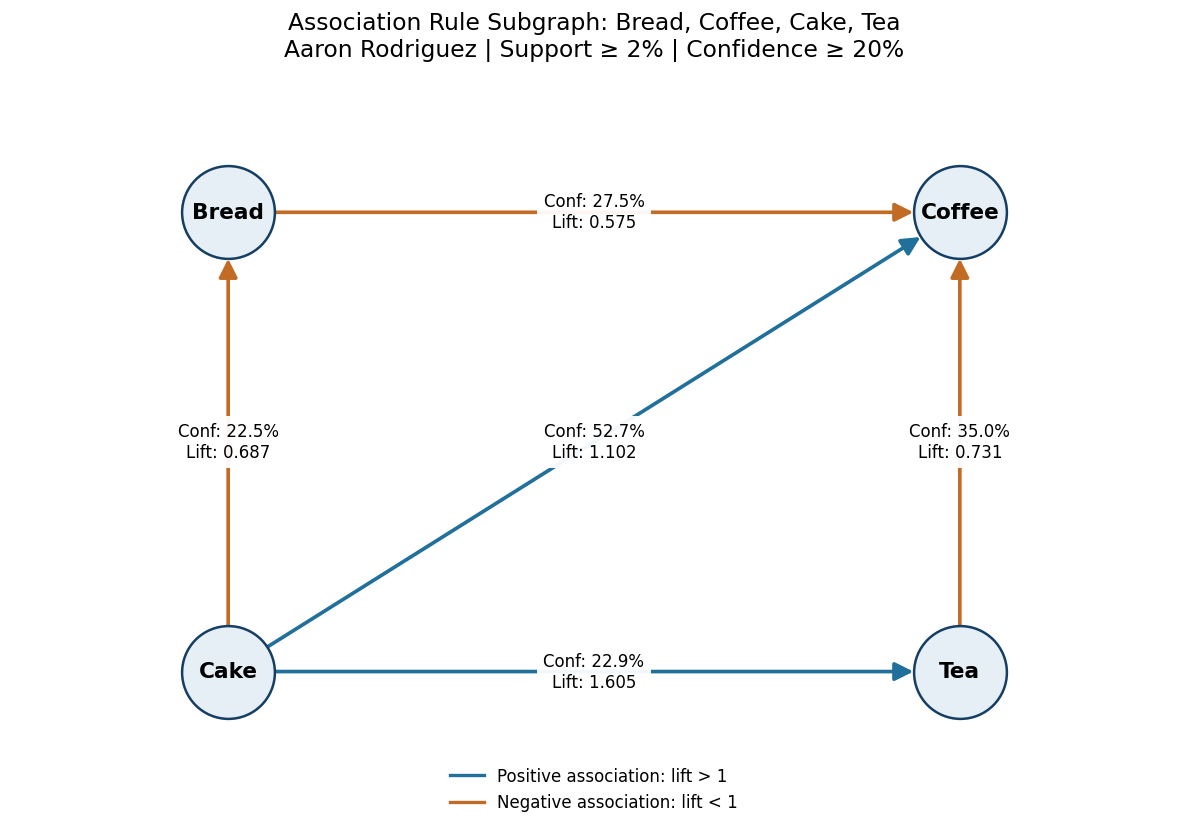

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


,Antecedent,Consequent,Support,Confidence,Lift
0,{Cake},{Tea},0.023772,0.228891,1.604781
1,{Cake},{Coffee},0.054728,0.526958,1.101515
2,{Tea},{Coffee},0.049868,0.349630,0.730840
3,{Cake},{Bread},0.023349,0.224822,0.687097
4,{Bread},{Coffee},0.090016,0.275105,0.575059


Subgraph: 4 nodes and 5 directed rules.


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

In [9]:
# Directed subgraph for the four requested items.
focus_items = {"Bread", "Coffee", "Cake", "Tea"}
focus_mask = (
    rules["antecedents"].map(lambda s: len(s) == 1 and s.issubset(focus_items))
    & rules["consequents"].map(lambda s: len(s) == 1 and s.issubset(focus_items))
)
focus_rules = rules.loc[focus_mask].copy()
G = nx.DiGraph()
G.add_nodes_from(sorted(focus_items))
for _, rule in focus_rules.iterrows():
    antecedent = next(iter(rule["antecedents"]))
    consequent = next(iter(rule["consequents"]))
    G.add_edge(antecedent, consequent,
               support=float(rule["support"]),
               confidence=float(rule["confidence"]),
               lift=float(rule["lift"]))

positions = {"Bread": (-1.1, 1.0), "Coffee": (1.1, 1.0),
             "Cake": (-1.1, -1.0), "Tea": (1.1, -1.0)}
fig, ax = plt.subplots(figsize=(10, 7))
nx.draw_networkx_nodes(G, positions, ax=ax, node_size=3100,
                       node_color="#e7eff6", edgecolors="#153e65", linewidths=1.5)
nx.draw_networkx_labels(G, positions, ax=ax, font_size=13, font_weight="bold")
edge_colors = ["#216f9b" if data["lift"] > 1 else "#c16b24"
               for _, _, data in G.edges(data=True)]
nx.draw_networkx_edges(G, positions, ax=ax, arrows=True, arrowsize=23,
                       node_size=3100, edge_color=edge_colors, width=2.2,
                       connectionstyle="arc3,rad=0.0")
edge_labels = {(a, b): f"Conf: {data['confidence']:.1%}\nLift: {data['lift']:.3f}"
               for a, b, data in G.edges(data=True)}
nx.draw_networkx_edge_labels(G, positions, edge_labels=edge_labels,
                             ax=ax, font_size=10, rotate=False,
                             bbox={"facecolor": "white", "edgecolor": "none", "alpha": 0.95})
ax.set_title("Association Rule Subgraph: Bread, Coffee, Cake, Tea\n"
             f"{subtitle} | Support ≥ 2% | Confidence ≥ 20%", fontsize=14, pad=18)
ax.legend(handles=[
    Line2D([0], [0], color="#216f9b", lw=2, label="Positive association: lift > 1"),
    Line2D([0], [0], color="#c16b24", lw=2, label="Negative association: lift < 1"),
], loc="lower center", bbox_to_anchor=(0.5, -0.04), frameon=False, fontsize=10)
ax.set_xlim(-1.75, 1.75)
ax.set_ylim(-1.55, 1.55)
ax.axis("off")
fig.tight_layout()
plt.show()
display(rule_report.loc[focus_mask, ["Antecedent", "Consequent", "Support", "Confidence", "Lift"]]
        .reset_index(drop=True).round(6))
print(f"Subgraph: {G.number_of_nodes()} nodes and {G.number_of_edges()} directed rules.")

## 6) Interpretation Prompt (5 pts)

**Interpret the rule `{Coffee, Cake} ⇒ {Bread}` in plain English.**

- **Support:** What fraction of all transactions contain Coffee, Cake, and Bread together?
- **Confidence:** Among baskets with Coffee and Cake, what share also include Bread?
- **Lift > 1** implies positive association; comment on practical meaning.

This specific rule is evaluated directly from the full basket matrix. Its
three-item support is below 2%, so it is absent from the mined rule report.
The mining threshold above is retained at the required 0.02.


In [10]:
# Exact metrics for the requested rule, even though it fails the mining threshold.
antecedent_mask = basket[["Coffee", "Cake"]].all(axis=1)
consequent_mask = basket["Bread"]
joint_count = int((antecedent_mask & consequent_mask).sum())
antecedent_count = int(antecedent_mask.sum())
consequent_count = int(consequent_mask.sum())
target_support = joint_count / n_transactions
target_confidence = joint_count / antecedent_count
bread_support = consequent_count / n_transactions
target_lift = target_confidence / bread_support

target_report = pd.DataFrame({
    "Rule": ["{Coffee, Cake} ⇒ {Bread}"],
    "All transactions": [n_transactions],
    "Coffee and Cake transactions": [antecedent_count],
    "Bread transactions": [consequent_count],
    "All three items": [joint_count],
    "Support": [target_support],
    "Confidence": [target_confidence],
    "Bread baseline support": [bread_support],
    "Lift": [target_lift],
})
display(target_report.round(6))
print(f"Support = {joint_count}/{n_transactions} = {target_support:.4%}")
print(f"Confidence = {joint_count}/{antecedent_count} = {target_confidence:.4%}")
print(f"Lift = ({joint_count}/{antecedent_count}) / "
      f"({consequent_count}/{n_transactions}) = {target_lift:.4f}")
print(f"Meets 2% support: {target_support >= MIN_SUPPORT}; "
      f"meets 20% confidence: {target_confidence >= MIN_CONFIDENCE}")

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

,Rule,All transactions,Coffee and Cake transactions,Bread transactions,All three items,Support,Confidence,Bread baseline support,Lift
0,"{Coffee, Cake} ⇒ {Bread}",9465,518,3097,95,0.010037,0.183398,0.327205,0.560497


Support = 95/9465 = 1.0037%
Confidence = 95/518 = 18.3398%
Lift = (95/518) / (3097/9465) = 0.5605
Meets 2% support: False; meets 20% confidence: False


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.13/dist-packag

**Interpretation:** The rule means that a transaction containing both Coffee
and Cake may also contain Bread. In this dataset, **95 of 9,465
transactions** contain all three items, giving a **support of 1.0037%**.
Among the **518 transactions containing Coffee and Cake**, 95
also contain Bread, so the **confidence is 18.3398%**.

Bread occurs in **32.72% of all transactions**, while it occurs in only
**18.34% of Coffee-and-Cake transactions**. The **lift is 0.5605**,
which indicates a **negative association**: Bread is about 44% less
likely in these baskets relative to its overall baseline. A lift greater than
1 would indicate positive association, but this rule's actual lift is below 1.

These results provide limited support for targeting Bread promotions at
customers buying Coffee and Cake. A small promotion test would be needed to
measure any benefit; the observed association does not show causation.
The rule fails both the 2% support threshold and the selected 20% confidence
threshold, which explains why it is absent from the main association-rule report.


### Implementation references

- Instructor-provided `bread_basket.csv` and `Assignment3_AssociationRuleMining_Template.ipynb`.
- Mlxtend: [FP-Growth documentation](https://rasbt.github.io/mlxtend/user_guide/frequent_patterns/fpgrowth/).
- Mlxtend: [Association-rule metrics and API documentation](https://rasbt.github.io/mlxtend/user_guide/frequent_patterns/association_rules/).

The analysis uses historical transactions from the supplied dataset. Run all
cells from top to bottom to reproduce the tables, plots, and interpretations.